<a href="https://colab.research.google.com/github/nataliakro02/lecture1/blob/drzewodecyzyjne/NK_15_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn import datasets
data = datasets.load_iris()

In [3]:
print(data)

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

In [15]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import math

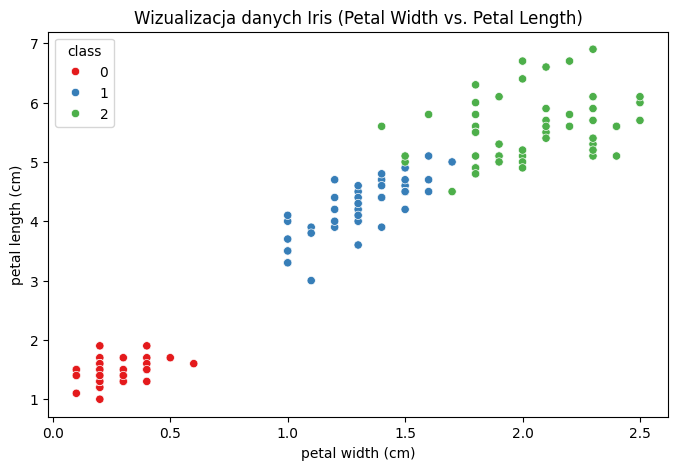

In [16]:
data = datasets.load_iris()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

df = pd.DataFrame(X, columns=feature_names)
df['class'] = y

# Wykres: petal width vs petal length
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='petal width (cm)', y='petal length (cm)', hue='class', palette='Set1')
plt.title('Wizualizacja danych Iris (Petal Width vs. Petal Length)')
plt.show()

In [23]:
def entropy(y):
    counts = Counter(y)
    total = len(y)
    return -sum((c / total) * math.log2(c / total) for c in counts.values())

# Funkcja do liczenia zysku informacyjnego
def information_gain(y, y_left, y_right):
    H_before = entropy(y)
    H_after = (len(y_left) / len(y)) * entropy(y_left) + (len(y_right) / len(y)) * entropy(y_right)
    return H_before - H_after

# Podziały po petal width (cm)
petal_width = X[:, 3]

# Podział A: <= 0.5
idx_a_left = petal_width <= 1.5
idx_a_right = petal_width > 1.5
gain_a = information_gain(y, y[idx_a_left], y[idx_a_right])

# Podział B: <= 0.38
idx_b_left = petal_width <= 0.38
idx_b_right = petal_width > 0.38
gain_b = information_gain(y, y[idx_b_left], y[idx_b_right])

# Wyświetlenie wyników
print(f"Zysk informacyjny dla podziału przy 1.5: {gain_a:.4f}")
print(f"Zysk informacyjny dla podziału przy 0.38: {gain_b:.4f}")

if information_gain1 > information_gain2:
    print(f"Podział na poziomie {threshold1} jest lepszy.")
elif information_gain2 > information_gain1:
    print(f"Podział na poziomie {threshold2} jest lepszy.")
else:
    print("Oba podziały są równie dobre.")

Zysk informacyjny dla podziału przy 1.5: 0.6656
Zysk informacyjny dla podziału przy 0.38: 0.6195
Podział na poziomie 1.5 jest lepszy.


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Drzewo decyzyjne
tree_clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
tree_acc = accuracy_score(y_test, y_pred_tree)

# Las losowy (15 drzew)
forest_clf = RandomForestClassifier(n_estimators=15, max_depth=3, random_state=42)
forest_clf.fit(X_train, y_train)
y_pred_forest = forest_clf.predict(X_test)
forest_acc = accuracy_score(y_test, y_pred_forest)

# Wyniki
print(f"Drzewo decyzyjne - dokładność: {tree_acc:.4f}")
print(f"Las losowy (15 drzew) - dokładność: {forest_acc:.4f}")

Drzewo decyzyjne - dokładność: 0.9778
Las losowy (15 drzew) - dokładność: 1.0000


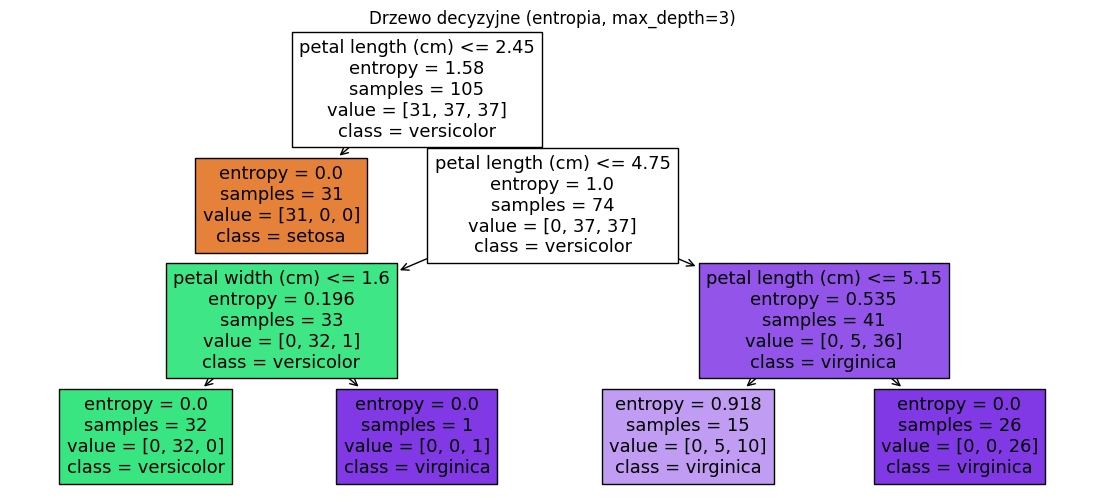

In [21]:
plt.figure(figsize=(14, 6))
plot_tree(tree_clf, feature_names=feature_names, class_names=target_names, filled=True)
plt.title("Drzewo decyzyjne (entropia, max_depth=3)")
plt.show()

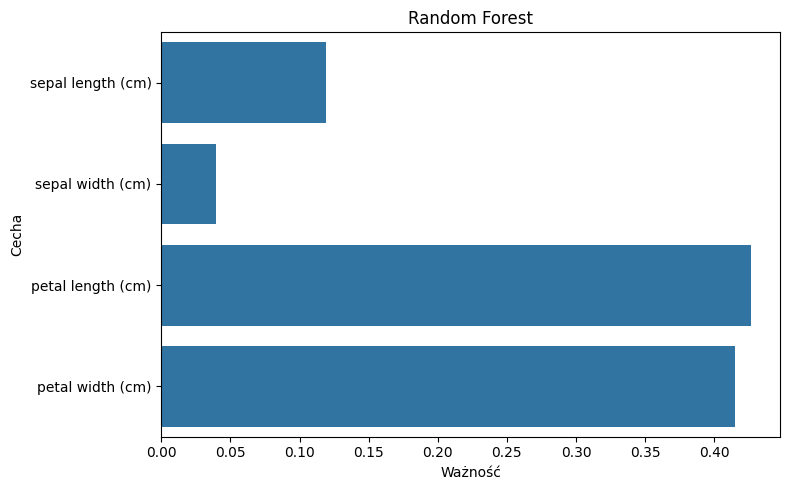

In [24]:
plt.figure(figsize=(8, 5))
sns.barplot(x=forest_clf.feature_importances_, y=feature_names)
plt.title("Random Forest")
plt.xlabel("Ważność")
plt.ylabel("Cecha")
plt.tight_layout()
plt.show()